In [1]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

# Single Run

In [2]:

key = jrandom.PRNGKey(1)
key, subkey = jrandom.split(key)



ref_model_analytic = Analytic(
    key=key,
    #type="RHE",
    #type="Rastrigin",
    type="Rosenbrock",
    #type="Ackley", 
    #type="CubicRankR"
    d=5,
    min_x=-1.5,
    max_x=2.5
)
#RHE: min_x = -5.0, max_x = 5.0
#Rastrigin: min_x = -5.12, max_x = 5.12
#Rosenbrock: min_x = -1.5, max_x = 2.5
#Ackley: min_x = -5.0, max_x = 5.0
#CubicRankR: min_x = -1.0, max_x = 1.0


#ref_model_mnist = MNIST_ref(
#    key=key, 
#    scale=0.5,
#    target_class=9
#)


#basket_dim = 1
#ref_model_heston = Heston(
#    key = key,
#    basket_dim=basket_dim,
#    basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
#    )

basket_dim = 7
ref_model_bachelier = Bachelier(
    key,
    basket_dim=basket_dim, 
    weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
)



ref_model = ref_model_bachelier
#ref_model = ref_model_heston
#ref_model = ref_model_analytic
#ref_model = ref_model_mnist





#test_set = ref_model.get_test_set(n_samples=128, order=2)
test_set = ref_model.get_test_set(n_samples=1*1024, order=2)

#if ref_model.was_normalized:
#    y_std = test_set[4]["y_std"]
#    ref_model.set_y_std(y_std)
#    print(y_std)

print("shapes:")
print("x:", test_set.x.shape)
print("y:", test_set.y.shape)
print("dydx:", test_set.dy.shape)
print("ddyddx:", "-" if test_set.ddy == None  else test_set.ddy.shape)
print("dddydddx:", "-" if test_set.dddy == None  else test_set.dddy.shape)



##train_sample_batch = ref_model.sample(key=key, n_samples=32)
#train_sample_batch = ref_model.sample(key=key, n_samples=256)



shapes:
x: (1024, 7)
y: (1024,)
dydx: (1024, 7)
ddyddx: (1024, 7, 7)
dddydddx: -


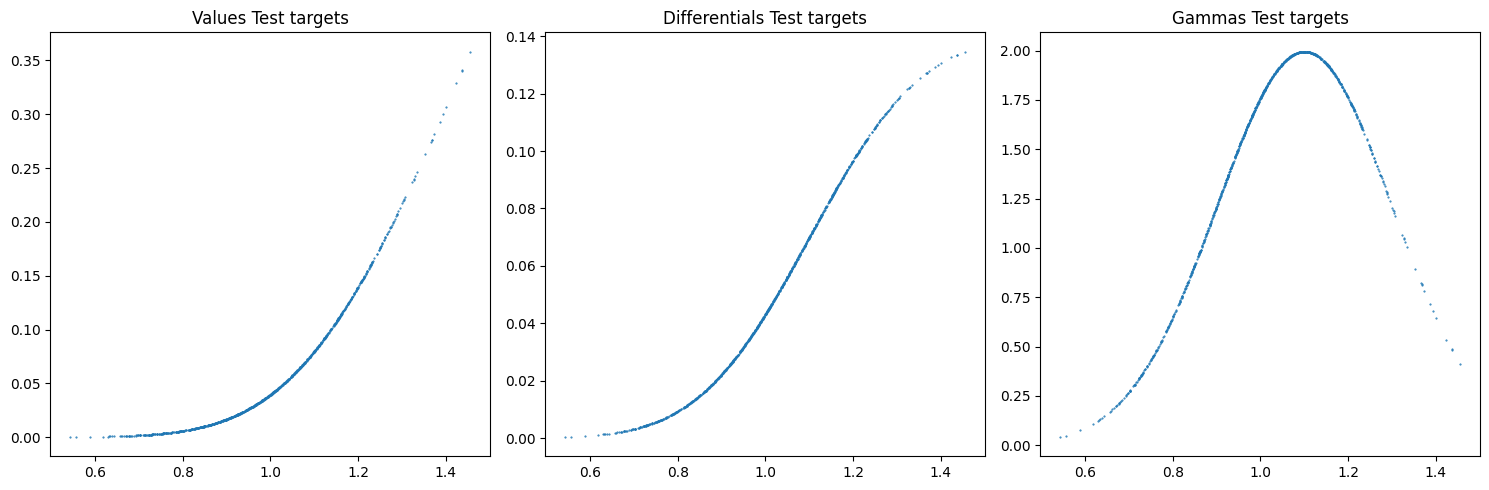

In [3]:
ref_model.visualize_data(test_set, name="Test targets")
#ref_model.visualize_dataset(train_sample_batch, name="Train", is_second_order=False)


In [4]:




#variant = "value"
#variant = "1st"
#variant = "random"
#variant = "pcady"
variant = "batchSVD"
#variant = "3rdBatchSVD"
#variant = "perXSVD"
#variant = "streaming"
#variant = "fullHessian"


learnable_loss_weights = False
k = 1
streaming_r = 2

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#8#32#32 # 32
BATCH_SIZE = 256#16#256#256 # 256
key = jrandom.PRNGKey(42)



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp



if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                ref_model=ref_model,
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None


optim = optax.adam(learning_rate=1e-3)



weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=BATCH_SIZE,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        learnable_loss_weights=learnable_loss_weights
                        )


Training for 100 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.02893 | Test Value Loss: 0.22882
Finished epoch 2 | Train Loss: 0.00478 | Test Value Loss: 0.04753
Finished epoch 3 | Train Loss: 0.00520 | Test Value Loss: 0.02427
Finished epoch 4 | Train Loss: 0.00481 | Test Value Loss: 0.02511
Finished epoch 5 | Train Loss: 0.00221 | Test Value Loss: 0.01688
Finished epoch 6 | Train Loss: 0.00308 | Test Value Loss: 0.02417
Finished epoch 7 | Train Loss: 0.00171 | Test Value Loss: 0.02161
Finished epoch 8 | Train Loss: 0.00271 | Test Value Loss: 0.02048
Finished epoch 9 | Train Loss: 0.00151 | Test Value Loss: 0.01602
Finished epoch 10 | Train Loss: 0.00136 | Test Value Loss: 0.01537
Finished epoch 11 | Train Loss: 0.00132 | Test Value Loss: 0.00857
Finished epoch 12 | Train Loss: 0.00146 | Test Value Loss: 0.00758
Finished epoch 13 | Train Loss: 0.00116 | Test Value Loss: 0.01059
Finished epoch 14 | Train Loss: 0.00129 | Test Value Loss: 0.00623
F

In [5]:
from diff_ml.utils import rmse
# eval price predictions
test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(weighted_model))(test_set.x)

test_pred_ddys = vmap(jax.hessian(MakeScalar(weighted_model)))(test_set.x)
test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)


test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(weighted_model))))(test_set.x)
#test_pred_dddys = test_pred_dddys.reshape(test_set[4].shape)


print("Test predictions shapes:")
print("test_pred_ys shape: ", test_pred_ys.shape)
print("test_pred_dys shape: ", test_pred_dys.shape)
print("test_pred_ddys shape: ", test_pred_ddys.shape)
#print("test_pred_dddys shape: ", test_pred_dddys.shape)

print("")

y_error = rmse(test_pred_ys, test_set.y)
dy_error = rmse(test_pred_dys, test_set.dy)
ddy_error = rmse(test_pred_ddys, test_set.ddy)
#dddy_error = rmse(test_pred_dddys, test_set[4])

print(f"test y error: {y_error:.5f}")
print(f"test dy error: {dy_error:.5f}")
print(f"test ddy error: {ddy_error:.5f}")
#print(f"test dddy error: {dddy_error:.5f}")



Test predictions shapes:
test_pred_ys shape:  (1024,)
test_pred_dys shape:  (1024, 7)
test_pred_ddys shape:  (1024, 7, 7)

test y error: 0.00395
test dy error: 0.00112
test ddy error: 0.00148


### balancing factors plot

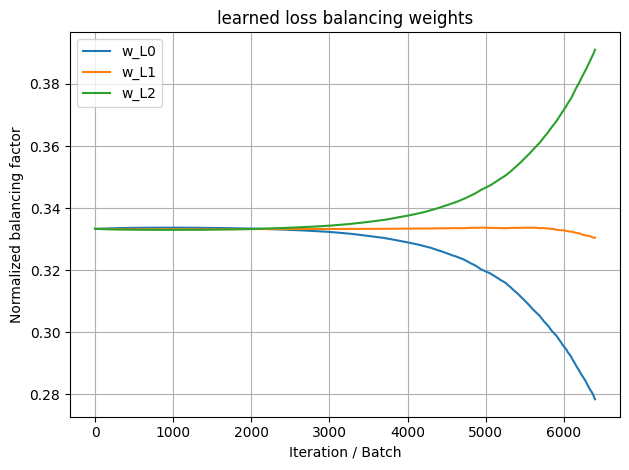

In [6]:
import matplotlib.pyplot as plt
ws = jnp.array([iteration_datas[t]["eff_w_norm"] for t in range(len(iteration_datas))])
active = (ws[0] != 0).astype(int)
ws = ws.T

for i, v in enumerate(active):
    if v:
        plt.plot(ws[i], label=f"w_L{i}")
        

plt.xlabel("Iteration / Batch")
plt.ylabel("Normalized balancing factor")
plt.title("learned loss balancing weights")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



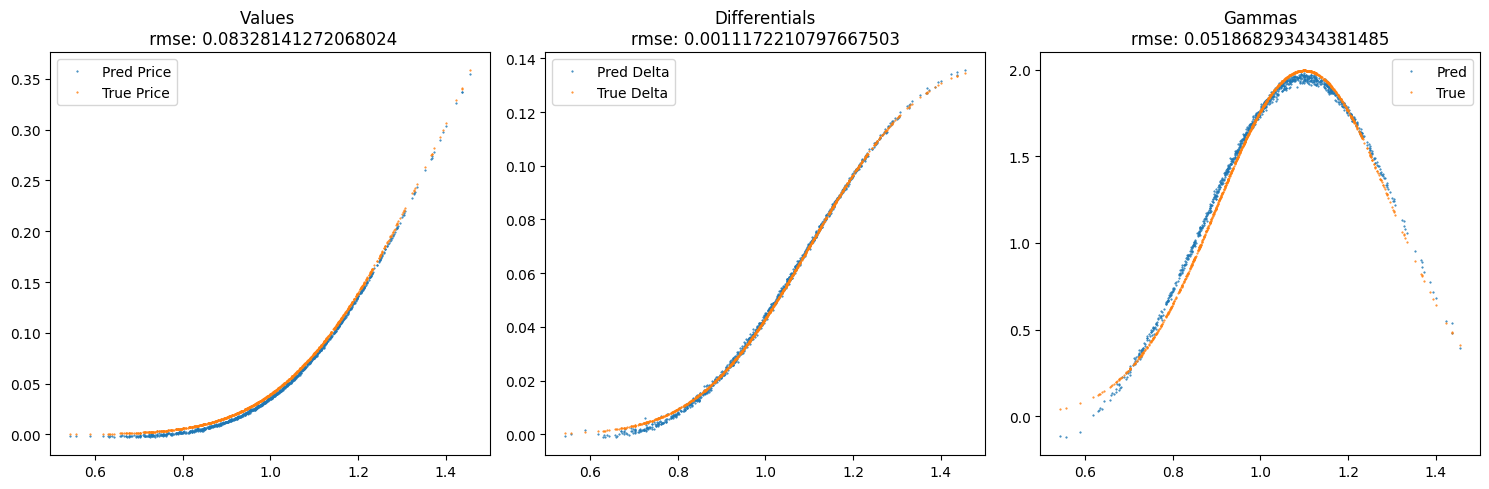

In [6]:
import matplotlib.pyplot as plt

ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_set)

# Averaged Runs

In [2]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order=2):
    
    basket_dim = 7
    ref_model = Bachelier(
        key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, test_set_order=2):
    basket_dim = 7
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if test_set_order ==3:
        test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    else:
        test_set = ref_model.get_test_set(n_samples=2*1024, order=test_set_order)
    #y_std = test_set[4]["y_std"]
    #ref_model.set_y_std(y_std)
    return ref_model, test_set
    
def make_analytic(key, test_set_order=2):
    ref_model = Analytic(
        key=key,
        #type="RHE",
        #type="Rastrigin",
        #type="Rosenbrock",
        #type="Ackley",
        type="CubicRankR",
        d=20,
        min_x=-1,
        max_x=1
    )
    #RHE: min_x = -5.0, max_x = 5.0
    ##Rastrigin: min_x = -5.12, max_x = 5.12
    #Rosenbrock: min_x = -1.5, max_x = 2.5
    #Ackley: min_x = -5.0, max_x = 5.0
    #CubicRankR: min_x = -1.0, max_x = 1.0

    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

### losses

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 1

n_epochs =  
n_batches_per_epoch = 32#8#32 # 32
BATCH_SIZE = 256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2



data = {}
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    test_losses_values = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key)
        #ref_model, test_set = make_heston(key)
        #ref_model, test_set = make_MNIST(key)
        #ref_model, test_set = make_analytic(key)


        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        fn=ref_model.reference_fn(), 
                        ref_model=ref_model,
                        d=ref_model.n_dims, 
                        r=streaming_r,
                        k=k, 
                        key=subkey)

        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        #test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        #test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


    
        test_losses_values.append(test_losses_value)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))
        


    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "avg_time_per_batch": avg_times_mean
    }

    



running variant value

run 1 / 1 for value
Training for 20 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.05097 | Test Value Loss: 0.19619
Finished epoch 2 | Train Loss: 0.01916 | Test Value Loss: 0.08216
Finished epoch 3 | Train Loss: 0.00886 | Test Value Loss: 0.05606
Finished epoch 4 | Train Loss: 0.00442 | Test Value Loss: 0.03340
Finished epoch 5 | Train Loss: 0.00410 | Test Value Loss: 0.02387
Finished epoch 6 | Train Loss: 0.00290 | Test Value Loss: 0.02405
Finished epoch 7 | Train Loss: 0.00326 | Test Value Loss: 0.02200
Finished epoch 8 | Train Loss: 0.00674 | Test Value Loss: 0.02288
Finished epoch 9 | Train Loss: 0.00352 | Test Value Loss: 0.02240
Finished epoch 10 | Train Loss: 0.00281 | Test Value Loss: 0.02619
Finished epoch 11 | Train Loss: 0.00206 | Test Value Loss: 0.01963
Finished epoch 12 | Train Loss: 0.00207 | Test Value Loss: 0.02486
Finished epoch 13 | Train Loss: 0.00225 | Test Value Loss: 0.01838
Finished epoch 14 | Train 

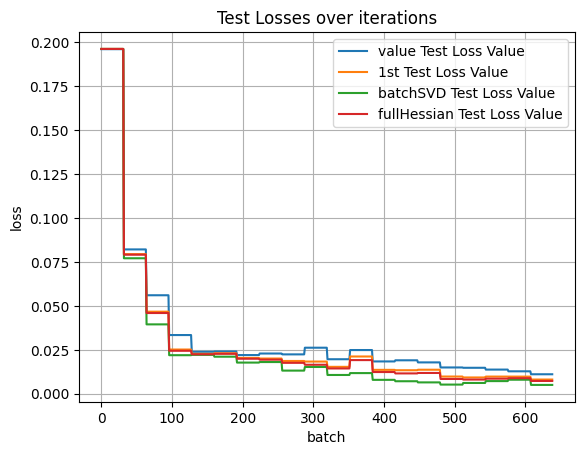

In [ ]:
#test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
#test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
#test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
#test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
#train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])

#epoch_cap = 32*50
epoch_cap = -1

for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    #test_losses_value_std = results["test_losses_values"][1]

    x = range(len(test_losses_value_mean))

    #plt.plot(x, train_losses, label='Train Loss', alpha=0.2)#, linestyle='-', marker='o')
    # Plot each of the three series
    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")#, linestyle='-', marker='o')
    #plt.plot(x, test_losses_grad, label='Test Loss Grad')#, linestyle='--', marker='s')
    #plt.plot(x, test_losses_hess, label='Test Loss Hess')#, linestyle=':', marker='^')
    #plt.plot(x, test_losses_proj_hess, label='Test Loss Proj Hess')#, linestyle=':', marker='^')


# Add labels & title
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('Test Losses over iterations')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


time per batch for value: 	0.00241s
time per batch for 1st: 	0.00260s
time per batch for batchSVD: 	0.00423s
time per batch for fullHessian: 	0.00554s


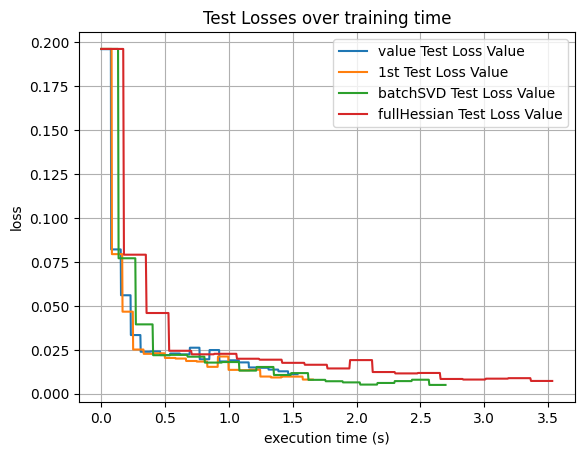

In [ ]:
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    time_per_batch = results["avg_time_per_batch"]
    print(f"time per batch for {variant}: \t{time_per_batch:.5f}s")
    #x = range(len(test_losses_value_mean))


    # TODO scale x axis by time per batch
    # Scale x-axis by execution time
    x = [i * time_per_batch for i in range(len(test_losses_value_mean))]


    

    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")
    


# Add labels & title
plt.xlabel('execution time (s)')
plt.ylabel('loss')
plt.title('Test Losses over training time')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


### all variants

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 5

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#8#4#32#8#32 # 32
BATCH_SIZE = 256#16#8#256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2
test_set_order = 3
learnable_loss_weights = False
do_approx_metrics = True
do_test_eval = True



data = {}
for variant in ["batchSVD"]:
#for variant in ["streaming"]:
#for variant in ["3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "pcady", "batchSVD", "perXSVD", "streaming", "fullHessian"]:#, "3rdBatchSVD"]:
    print("running variant", variant)
    
    y_errors = []
    dy_errors = []
    ddy_errors = []
    dddy_errors = []
    eFs = []
    e2s = []
    evrs = []
    engs = []
    avg_t_p_bs = []

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key=key, test_set_order=test_set_order)
        #ref_model, test_set = make_heston(key, test_set_order=test_set_order)
        #ref_model, test_set = make_analytic(key, test_set_order=test_set_order)
        #ref_model, test_set = make_MNIST(key, test_set_order=test_set_order)
        

        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
    
        
        # eval price predictions
        test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
        test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
        test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)



        y_error = jnp.sqrt(mse(test_pred_ys, test_set.y))
        dy_error = jnp.sqrt(mse(test_pred_dys, test_set.dy))
        ddy_error = jnp.sqrt(mse(test_pred_ddys, test_set.ddy))

        if test_set_order > 2:
            test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
            dddy_error = jnp.sqrt(mse(test_pred_dddys, test_set.dddy))        
        else:
            dddy_error = jnp.nan

        y_errors.append(y_error)
        dy_errors.append(dy_error)
        ddy_errors.append(ddy_error)
        dddy_errors.append(dddy_error)
        print(f"test y error: {y_error:.5f}")
        print(f"test dy error: {dy_error:.5f}")
        print(f"test ddy error: {ddy_error:.5f}")
        if test_set_order > 2:
            print(f"test dddy error: {dddy_error:.5f}")
    
        #print(iteration_datas[0])
        if "approximation metrics ref" in iteration_datas[0]:
            epochs = list(range(len(iteration_datas)))
            eF_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["eF mean"]  for t in epochs])
            e2_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["e2 mean"]  for t in epochs])
            evr_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["evr mean"] for t in epochs])
            eng_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["eng mean"] for t in epochs])
            mean_eF  = jnp.nanmean(eF_vals)
            mean_e2  = jnp.nanmean(e2_vals)
            mean_evr = jnp.nanmean(evr_vals)
            mean_eng = jnp.nanmean(eng_vals)
        else:
            mean_eF  = 0.0
            mean_e2  = 0.0
            mean_evr = 0.0
            mean_eng = 0.0
        eFs.append(mean_eF)
        e2s.append(mean_e2)
        evrs.append(mean_evr)
        engs.append(mean_eng)
        print(f"eF: {mean_eF:.5f}")
        print(f"e2: {mean_e2:.5f}")
        print(f"evr: {mean_evr:.5f}")
        print(f"eng: {mean_eng:.5f}")
        avg_t_p_bs.append(avg_time_per_batch)
        print(f"avg time per batch: {avg_time_per_batch:.5f}")

    # average the runs
    print("")
    y_errors = jnp.array(y_errors)
    dy_errors = jnp.array(dy_errors)
    ddy_errors = jnp.array(ddy_errors)
    dddy_errors = jnp.array(dddy_errors)

    y_errors_mean = y_errors.mean()
    dy_errors_mean = dy_errors.mean()
    ddy_errors_mean = ddy_errors.mean()
    dddy_errors_mean = dddy_errors.mean()
    y_errors_std = y_errors.std()
    dy_errors_std = dy_errors.std()
    ddy_errors_std = ddy_errors.std()
    dddy_errors_std = dddy_errors.std()

    print(f"y errors: \tmean: {y_errors_mean:.5f} \tstd: {y_errors_std:.5f}")
    print(f"dy errors: \tmean: {dy_errors_mean:.5f} \tstd: {dy_errors_std:.5f}")
    print(f"ddy errors: \tmean: {ddy_errors_mean:.5f} \tstd: {ddy_errors_std:.5f}")
    if test_set_order > 2:
        print(f"dddy errors: \tmean: {dddy_errors_mean:.5f} \tstd: {dddy_errors_std:.5f}")


    eFs = jnp.array(eFs)
    e2s = jnp.array(e2s)
    evrs = jnp.array(evrs)
    engs = jnp.array(engs)

    eFs_mean = eFs.mean()
    e2s_mean = e2s.mean()
    evrs_mean = evrs.mean()
    engs_mean = engs.mean()
    eFs_std = eFs.std()
    e2s_std = e2s.std()
    evrs_std = evrs.std()
    engs_std = engs.std()

    print(f"eFs: \tmean: {eFs_mean:.5f} \tstd: {eFs_std:.5f}")
    print(f"e2s: \tmean: {e2s_mean:.5f} \tstd: {e2s_std:.5f}")
    print(f"evrs: \tmean: {evrs_mean:.5f} \tstd: {evrs_std:.5f}")
    print(f"engs: \tmean: {engs_mean:.5f} \tstd: {engs_std:.5f}")

    avg_t_p_bs = jnp.array(avg_t_p_bs)


    print(f"avg time per batch: {avg_t_p_bs.mean():.5f}")



        


    data[variant] = {
        "y errors":   (y_errors_mean, y_errors_std),
        "dy errors":  (dy_errors_mean, dy_errors_std),
        "ddy errors": (ddy_errors_mean, ddy_errors_std),
        "dddy errors": (dddy_errors_mean, dddy_errors_std),
        "eFs":  (eFs_mean, eFs_std),
        "e2s":  (e2s_mean, e2s_std),
        "evrs": (evrs_mean, evrs_std),
        "engs": (engs_mean, engs_std),
        "avg time per batch": avg_t_p_bs.mean(),
    }

    



running variant batchSVD

run 1 / 5 for batchSVD
Training for 100 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.02810 | Test Value Loss: 0.19715
Finished epoch 2 | Train Loss: 0.00779 | Test Value Loss: 0.08380
Finished epoch 3 | Train Loss: 0.00399 | Test Value Loss: 0.04362
Finished epoch 4 | Train Loss: 0.00279 | Test Value Loss: 0.03481
Finished epoch 5 | Train Loss: 0.00195 | Test Value Loss: 0.03109
Finished epoch 6 | Train Loss: 0.00183 | Test Value Loss: 0.02181
Finished epoch 7 | Train Loss: 0.00173 | Test Value Loss: 0.02167
Finished epoch 8 | Train Loss: 0.00136 | Test Value Loss: 0.02585
Finished epoch 9 | Train Loss: 0.00161 | Test Value Loss: 0.02093
Finished epoch 10 | Train Loss: 0.00115 | Test Value Loss: 0.02225
Finished epoch 11 | Train Loss: 0.00136 | Test Value Loss: 0.01819
Finished epoch 12 | Train Loss: 0.00140 | Test Value Loss: 0.01772
Finished epoch 13 | Train Loss: 0.00139 | Test Value Loss: 0.01662
Finished epoch 14 |

### formatting

In [4]:
key_map = {
    "y errors": "y_error",
    "dy errors": "dy_error",
    "ddy errors": "ddy_error",
    "eFs": "eFs",
    "e2s": "e2s",
    "evrs": "evrs",
    "engs": "engs",    
    "avg time per batch": "time_p_b"
}

variant_nicknames = {
    "3rdBatchSVD": "t3BatchSVD",
    "fullHessian": "fullHessian",
    "streaming": "streaming",
    "perXSVD": "perxRandSVD",
    "batchSVD": "batchRandSVD",
    "pcady": "pcady",
    "random": "random",
    "1st": "1st",
    "value": "value",
}

# variants that should only get y/dy/ddy errors
restricted_keys_variants = {"fullHessian", "1st", "value"}

def format_results(data, name):
    lines = []
    all_prefixes = []

    # Collect all var_prefix strings first
    for variant, results in reversed(list(data.items())):
        for k in results.keys():
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors"):
                continue
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix = f"{name}_{variant}_{suffix}"
            all_prefixes.append(var_prefix)

    # Find the maximum length for alignment
    max_len = max(len(p) for p in all_prefixes)
    max_len += 6 # account for '_mean'

    # Build the output with alignment
    for variant, results in reversed(list(data.items())):
        
        label = f"# {variant}"
        lines.append(label)
        variant_nickname = variant_nicknames.get(variant)

        for k, v in results.items():
            #(mean, std) = v
            if type(v) == tuple:
                mean, std = v 
            else:
                mean = v
                std = .0
            
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors", "avg time per batch"):
                continue
            if k in ("eFs", "e2s", "evrs", "engs"):
                offset = 0
            else:
                offset = 4
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix_mean = f"{name}_{variant_nickname}_{suffix}_mean"
            var_prefix_std = f"{name}_{variant_nickname}_{suffix}_std"
            
            # Pad with spaces so all "=" align
            lines.append(
                f"{var_prefix_mean.ljust(max_len)}, {var_prefix_std.ljust(max_len)} {''.ljust(offset)} = {mean:.5f}, {std:.5f}"
            )

        #lines.append("")  # blank line after each block

    return "\n".join(lines)
print(format_results(data, name="bachelier7"))

# batchSVD
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00676, 0.00322
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00893, 0.00422
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01041, 0.00407
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01137, 0.00280
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00362, 0.00000


### res

## 8th learnable balancing

In [1]:
import jax.numpy as jnp
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
bachelier_t3BatchSVD_y_error_mean      , bachelier_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dy_error_mean     , bachelier_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_ddy_error_mean    , bachelier_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dddy_errors_mean  , bachelier_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
bachelier_t3BatchSVD_eFs_mean          , bachelier_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_e2s_mean          , bachelier_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_evrs_mean         , bachelier_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_engs_mean         , bachelier_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_time_p_b_mean     , bachelier_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00339, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00211, 0.00085
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00187, 0.00069
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00616, 0.00000
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00229, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00339, 0.00164
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00211, 0.00085
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00187, 0.00069
bachelier_streaming_dddy_errors_mean , bachelier_streaming_dddy_errors_std        = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00019, 0.00006
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00019, 0.00006
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99709, 0.00022
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02167, 0.00000
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.00252, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00339, 0.00164
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00211, 0.00085
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00187, 0.00069
bachelier_perxRandSVD_dddy_errors_mean, bachelier_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99708, 0.00026
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03759, 0.00000
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.01759, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00288, 0.00158
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00174, 0.00067
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00105, 0.00031
bachelier_batchRandSVD_dddy_errors_mean, bachelier_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99859, 0.00005
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00745, 0.00000
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00332, 0.00000
# pcady
bachelier_pcady_y_error_mean         , bachelier_pcady_y_error_std                = 0.00295, 0.00161
bachelier_pcady_dy_error_mean        , bachelier_pcady_dy_error_std               = 0.00178, 0.00067
bachelier_pcady_ddy_error_mean       , bachelier_pcady_ddy_error_std              = 0.00106, 0.00032
bachelier_pcady_dddy_errors_mean     , bachelier_pcady_dddy_errors_std            = jnp.nan, jnp.nan
bachelier_pcady_eFs_mean             , bachelier_pcady_eFs_std                = 0.00071, 0.00004
bachelier_pcady_e2s_mean             , bachelier_pcady_e2s_std                = 0.00071, 0.00004
bachelier_pcady_evrs_mean            , bachelier_pcady_evrs_std               = 1.00000, 0.00000
bachelier_pcady_engs_mean            , bachelier_pcady_engs_std               = 0.99859, 0.00005
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00737, 0.00000
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00363, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00341, 0.00168
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00213, 0.00088
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00189, 0.00070
bachelier_random_dddy_errors_mean    , bachelier_random_dddy_errors_std           = jnp.nan, jnp.nan
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92098, 0.00196
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92098, 0.00196
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14200, 0.00319
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14180, 0.00319
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00659, 0.00000
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00240, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00372, 0.00182
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00255, 0.00097
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00291, 0.00095
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00444, 0.00000
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00224, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00545, 0.00232
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00414, 0.00080
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00532, 0.00112
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00376, 0.00000
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00191, 0.00000

# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston1_t3BatchSVD_y_error_mean      , heston1_t3BatchSVD_y_error_std             = 0.00272, 0.00235
heston1_t3BatchSVD_dy_error_mean     , heston1_t3BatchSVD_dy_error_std            = 0.00175, 0.00116
heston1_t3BatchSVD_ddy_error_mean    , heston1_t3BatchSVD_ddy_error_std           = 0.00257, 0.00057
heston1_t3BatchSVD_dddy_errors_mean  , heston1_t3BatchSVD_dddy_errors_std         = 0.01295, 0.00174
heston1_t3BatchSVD_eFs_mean          , heston1_t3BatchSVD_eFs_std             = 0.26298, 0.00212
heston1_t3BatchSVD_e2s_mean          , heston1_t3BatchSVD_e2s_std             = 0.26655, 0.00212
heston1_t3BatchSVD_evrs_mean         , heston1_t3BatchSVD_evrs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_engs_mean         , heston1_t3BatchSVD_engs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_time_p_b_mean     , heston1_t3BatchSVD_time_p_b_std            = 0.01209, 0.00000
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00210, 0.00145
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00160, 0.00076
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00341, 0.00052
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00677, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00151, 0.00053
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00110, 0.00024
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00335, 0.00059
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00007
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00008
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00021
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.02205, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00151, 0.00053
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00110, 0.00024
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00335, 0.00059
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20976, 0.00019
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21294, 0.00020
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90807, 0.00021
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81128, 0.00026
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.03658, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00230, 0.00083
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00165, 0.00048
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.00519, 0.00086
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26298, 0.00212
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26655, 0.00212
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89151, 0.00211
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89151, 0.00211
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00781, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00151, 0.00095
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00151, 0.00032
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.00561, 0.00100
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22756, 0.00018
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23104, 0.00019
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92084, 0.00012
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92084, 0.00012
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00808, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00160, 0.00101
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00140, 0.00048
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00362, 0.00058
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = jnp.nan, jnp.nan
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64556, 0.00277
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65069, 0.00279
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49792, 0.00301
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49792, 0.00301
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00712, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00253, 0.00208
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00304, 0.00133
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.01125, 0.00179
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00399, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00292, 0.00097
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.00830, 0.00250
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.02737, 0.00787
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00329, 0.00000

# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston2_t3BatchSVD_y_error_mean      , heston2_t3BatchSVD_y_error_std             = 0.00308, 0.00107
heston2_t3BatchSVD_dy_error_mean     , heston2_t3BatchSVD_dy_error_std            = 0.00318, 0.00058
heston2_t3BatchSVD_ddy_error_mean    , heston2_t3BatchSVD_ddy_error_std           = 0.00590, 0.00095
heston2_t3BatchSVD_dddy_errors_mean  , heston2_t3BatchSVD_dddy_errors_std         = 0.01290, 0.00166
heston2_t3BatchSVD_eFs_mean          , heston2_t3BatchSVD_eFs_std             = 0.64692, 0.06221
heston2_t3BatchSVD_e2s_mean          , heston2_t3BatchSVD_e2s_std             = 0.71475, 0.09256
heston2_t3BatchSVD_evrs_mean         , heston2_t3BatchSVD_evrs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_engs_mean         , heston2_t3BatchSVD_engs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_time_p_b_mean     , heston2_t3BatchSVD_time_p_b_std            = 0.01161, 0.00000
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00257, 0.00073
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00333, 0.00037
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00727, 0.00086
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.03921, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00257, 0.00073
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00333, 0.00037
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00727, 0.00086
heston2_streaming_dddy_errors_mean , heston2_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48112, 0.06025
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.51728, 0.08179
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73995, 0.05302
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.59283, 0.10343
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.06107, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00257, 0.00073
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00333, 0.00037
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00727, 0.00086
heston2_perxRandSVD_dddy_errors_mean, heston2_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58080, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65375, 0.07768
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61912, 0.04665
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49745, 0.05733
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.05391, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00319, 0.00105
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00372, 0.00035
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00783, 0.00075
heston2_batchRandSVD_dddy_errors_mean, heston2_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64691, 0.06221
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71475, 0.09256
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54400, 0.06756
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54400, 0.06756
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.06049, 0.00000
# pcady
heston2_pcady_y_error_mean         , heston2_pcady_y_error_std                = 0.00324, 0.00103
heston2_pcady_dy_error_mean        , heston2_pcady_dy_error_std               = 0.00472, 0.00075
heston2_pcady_ddy_error_mean       , heston2_pcady_ddy_error_std              = 0.00953, 0.00138
heston2_pcady_dddy_errors_mean     , heston2_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston2_pcady_eFs_mean             , heston2_pcady_eFs_std                = 0.53839, 0.10582
heston2_pcady_e2s_mean             , heston2_pcady_e2s_std                = 0.59004, 0.14280
heston2_pcady_evrs_mean            , heston2_pcady_evrs_std               = 0.65661, 0.11064
heston2_pcady_engs_mean            , heston2_pcady_engs_std               = 0.65661, 0.11064
heston2_pcady_time_p_b_mean        , heston2_pcady_time_p_b_std               = 0.04892, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00361, 0.00158
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00352, 0.00038
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00738, 0.00084
heston2_random_dddy_errors_mean    , heston2_random_dddy_errors_std           = jnp.nan, jnp.nan
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85727, 0.00218
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88457, 0.01109
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24941, 0.00178
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24941, 0.00178
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.04573, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00396, 0.00131
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00600, 0.00072
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01241, 0.00134
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00792, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00657, 0.00119
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01362, 0.00210
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02543, 0.00366
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00318, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=2, r=4
# 3rdBatchSVD
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.01327, 0.00162
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.00863, 0.00059
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.00613, 0.00043
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00475, 0.00033
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77980, 0.01835
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.83901, 0.02362
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00795, 0.00000
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00519, 0.00000
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.01921, 0.00146
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.01350, 0.00109
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.01015, 0.00084
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00568, 0.00000
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00330, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.01921, 0.00146
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01350, 0.00109
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.01015, 0.00084
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66079, 0.02849
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.69360, 0.04387
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.55656, 0.03589
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.40795, 0.02856
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.02146, 0.00000
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.00367, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.01921, 0.00146
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.01350, 0.00109
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.01015, 0.00084
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.70098, 0.01742
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.76232, 0.02458
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.49776, 0.02287
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.35090, 0.02219
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.03535, 0.00000
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.01921, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.01850, 0.00153
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.01268, 0.00093
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.00932, 0.00075
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.77978, 0.01825
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.83902, 0.02354
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.38483, 0.02718
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.38483, 0.02718
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00861, 0.00000
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00384, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.01861, 0.00112
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01307, 0.00097
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.00964, 0.00094
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67097, 0.03995
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72425, 0.05690
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52929, 0.05128
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52929, 0.05128
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00798, 0.00000
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00384, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.01926, 0.00151
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.01351, 0.00109
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.01015, 0.00085
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = jnp.nan, jnp.nan
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92534, 0.00025
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94258, 0.00183
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14227, 0.00046
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14227, 0.00046
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00699, 0.00000
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00239, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.01997, 0.00142
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01444, 0.00122
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.01105, 0.00094
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00392, 0.00000
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00247, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.02255, 0.00191
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.01743, 0.00157
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01338, 0.00109
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00314, 0.00000
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00220, 0.00000

# MNIST | epochs=100, n_batches_per_epoch=8, batch_size=16
# k=5, r=8
# 3rdBatchSVD
mnist_t3BatchSVD_y_error_mean      , mnist_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_dy_error_mean     , mnist_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_ddy_error_mean    , mnist_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
mnist_t3BatchSVD_dddy_errors_mean  , mnist_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
mnist_t3BatchSVD_eFs_mean          , mnist_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_e2s_mean          , mnist_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_evrs_mean         , mnist_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_engs_mean         , mnist_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_time_p_b_mean     , mnist_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
mnist_fullHessian_y_error_mean   , mnist_fullHessian_y_error_std          = 0.50945, 0.05798
mnist_fullHessian_dy_error_mean  , mnist_fullHessian_dy_error_std         = 0.22570, 0.00949
mnist_fullHessian_ddy_error_mean , mnist_fullHessian_ddy_error_std        = 0.04927, 0.00285
mnist_fullHessian_time_p_b_mean  , mnist_fullHessian_time_p_b_std         = 0.02140, 0.00000
# streaming
mnist_streaming_y_error_mean     , mnist_streaming_y_error_std            = 0.50943, 0.05798
mnist_streaming_dy_error_mean    , mnist_streaming_dy_error_std           = 0.22570, 0.00949
mnist_streaming_ddy_error_mean   , mnist_streaming_ddy_error_std          = 0.04926, 0.00285
mnist_streaming_dddy_errors_mean , mnist_streaming_dddy_errors_std        = jnp.nan, jnp.nan
mnist_streaming_eFs_mean         , mnist_streaming_eFs_std            = 0.78491, 0.01466
mnist_streaming_e2s_mean         , mnist_streaming_e2s_std            = 0.74538, 0.02475
mnist_streaming_evrs_mean        , mnist_streaming_evrs_std           = 0.38080, 0.02266
mnist_streaming_engs_mean        , mnist_streaming_engs_std           = 0.30622, 0.01941
mnist_streaming_time_p_b_mean    , mnist_streaming_time_p_b_std           = 0.28594, 0.00000
# perXSVD
mnist_perxRandSVD_y_error_mean  , mnist_perxRandSVD_y_error_std         = 0.50941, 0.05798
mnist_perxRandSVD_dy_error_mean , mnist_perxRandSVD_dy_error_std        = 0.22570, 0.00948
mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std       = 0.04927, 0.00285
mnist_perxRandSVD_dddy_errors_mean, mnist_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_perxRandSVD_eFs_mean      , mnist_perxRandSVD_eFs_std         = 0.72194, 0.01004
mnist_perxRandSVD_e2s_mean      , mnist_perxRandSVD_e2s_std         = 0.68714, 0.01237
mnist_perxRandSVD_evrs_mean     , mnist_perxRandSVD_evrs_std        = 0.47401, 0.01421
mnist_perxRandSVD_engs_mean     , mnist_perxRandSVD_engs_std        = 0.23889, 0.01249
mnist_perxRandSVD_time_p_b_mean , mnist_perxRandSVD_time_p_b_std        = 0.27247, 0.00000
# batchSVD
mnist_batchRandSVD_y_error_mean , mnist_batchRandSVD_y_error_std        = 0.50941, 0.05747
mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std       = 0.22301, 0.00951
mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std      = 0.04810, 0.00268
mnist_batchRandSVD_dddy_errors_mean, mnist_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_batchRandSVD_eFs_mean     , mnist_batchRandSVD_eFs_std        = 0.83915, 0.01162
mnist_batchRandSVD_e2s_mean     , mnist_batchRandSVD_e2s_std        = 0.82296, 0.01671
mnist_batchRandSVD_evrs_mean    , mnist_batchRandSVD_evrs_std       = 0.29316, 0.01920
mnist_batchRandSVD_engs_mean    , mnist_batchRandSVD_engs_std       = 0.29316, 0.01920
mnist_batchRandSVD_time_p_b_mean, mnist_batchRandSVD_time_p_b_std       = 0.25183, 0.00000
# pcady
mnist_pcady_y_error_mean        , mnist_pcady_y_error_std               = 0.50945, 0.05730
mnist_pcady_dy_error_mean       , mnist_pcady_dy_error_std              = 0.22252, 0.00946
mnist_pcady_ddy_error_mean      , mnist_pcady_ddy_error_std             = 0.04810, 0.00269
mnist_pcady_dddy_errors_mean    , mnist_pcady_dddy_errors_std           = jnp.nan, jnp.nan
mnist_pcady_eFs_mean            , mnist_pcady_eFs_std               = 0.84874, 0.00682
mnist_pcady_e2s_mean            , mnist_pcady_e2s_std               = 0.83129, 0.01199
mnist_pcady_evrs_mean           , mnist_pcady_evrs_std              = 0.27712, 0.01139
mnist_pcady_engs_mean           , mnist_pcady_engs_std              = 0.27712, 0.01139
mnist_pcady_time_p_b_mean       , mnist_pcady_time_p_b_std              = 0.25234, 0.00000
# random
mnist_random_y_error_mean     , mnist_random_y_error_std            = 0.50942, 0.05800
mnist_random_dy_error_mean    , mnist_random_dy_error_std           = 0.22572, 0.00950
mnist_random_ddy_error_mean   , mnist_random_ddy_error_std          = 0.04928, 0.00285
mnist_random_dddy_errors_mean , mnist_random_dddy_errors_std        = jnp.nan, jnp.nan
mnist_random_eFs_mean         , mnist_random_eFs_std            = 0.98714, 0.00004
mnist_random_e2s_mean         , mnist_random_e2s_std            = 0.98761, 0.00011
mnist_random_evrs_mean        , mnist_random_evrs_std           = 0.02551, 0.00008
mnist_random_engs_mean        , mnist_random_engs_std           = 0.02551, 0.00008
mnist_random_time_p_b_mean    , mnist_random_time_p_b_std           = 0.25073, 0.00000
# 1st
mnist_1st_y_error_mean        , mnist_1st_y_error_std               = 0.50931, 0.05810
mnist_1st_dy_error_mean       , mnist_1st_dy_error_std              = 0.22622, 0.00953
mnist_1st_ddy_error_mean      , mnist_1st_ddy_error_std             = 0.04951, 0.00289
mnist_1st_time_p_b_mean       , mnist_1st_time_p_b_std              = 0.01074, 0.00000
# value
mnist_value_y_error_mean      , mnist_value_y_error_std             = 0.51207, 0.06029
mnist_value_dy_error_mean     , mnist_value_dy_error_std            = 0.29483, 0.01783
mnist_value_ddy_error_mean    , mnist_value_ddy_error_std           = 0.06466, 0.00634
mnist_value_time_p_b_mean     , mnist_value_time_p_b_std            = 0.00845, 0.00000


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRHE_t3BatchSVD_y_error_mean      , analyticRHE_t3BatchSVD_y_error_std             = 0.02404, 0.00272
analyticRHE_t3BatchSVD_dy_error_mean     , analyticRHE_t3BatchSVD_dy_error_std            = 0.01566, 0.00189
analyticRHE_t3BatchSVD_ddy_error_mean    , analyticRHE_t3BatchSVD_ddy_error_std           = 0.00983, 0.00130
analyticRHE_t3BatchSVD_dddy_errors_mean  , analyticRHE_t3BatchSVD_dddy_errors_std         = 0.00528, 0.00070
analyticRHE_t3BatchSVD_eFs_mean          , analyticRHE_t3BatchSVD_eFs_std             = 0.74052, 0.00037
analyticRHE_t3BatchSVD_e2s_mean          , analyticRHE_t3BatchSVD_e2s_std             = 0.87315, 0.00053
analyticRHE_t3BatchSVD_evrs_mean         , analyticRHE_t3BatchSVD_evrs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_engs_mean         , analyticRHE_t3BatchSVD_engs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_time_p_b_mean     , analyticRHE_t3BatchSVD_time_p_b_std            = 0.00843, 0.00000
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02525, 0.00267
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.01686, 0.00200
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01105, 0.00148
analyticRHE_fullHessian_time_p_b_mean  , analyticRHE_fullHessian_time_p_b_std         = 0.00420, 0.00000
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02513, 0.00272
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.01686, 0.00203
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01105, 0.00148
analyticRHE_streaming_dddy_errors_mean , analyticRHE_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67499, 0.01953
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.78877, 0.04824
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54319, 0.02638
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54319, 0.02638
analyticRHE_streaming_time_p_b_mean    , analyticRHE_streaming_time_p_b_std           = 0.01947, 0.00000
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02513, 0.00272
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.01686, 0.00203
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01105, 0.00148
analyticRHE_perxRandSVD_dddy_errors_mean, analyticRHE_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74040, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87297, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_time_p_b_mean  , analyticRHE_perxRandSVD_time_p_b_std         = 0.03484, 0.00000
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02537, 0.00249
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.01645, 0.00180
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01063, 0.00141
analyticRHE_batchRandSVD_dddy_errors_mean, analyticRHE_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74052, 0.00037
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87315, 0.00053
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_time_p_b_mean , analyticRHE_batchRandSVD_time_p_b_std        = 0.00615, 0.00000
# pcady
analyticRHE_pcady_y_error_mean         , analyticRHE_pcady_y_error_std                = 0.02423, 0.00219
analyticRHE_pcady_dy_error_mean        , analyticRHE_pcady_dy_error_std               = 0.01615, 0.00184
analyticRHE_pcady_ddy_error_mean       , analyticRHE_pcady_ddy_error_std              = 0.01040, 0.00140
analyticRHE_pcady_dddy_errors_mean     , analyticRHE_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRHE_pcady_eFs_mean             , analyticRHE_pcady_eFs_std                = 0.60986, 0.00004
analyticRHE_pcady_e2s_mean             , analyticRHE_pcady_e2s_std                = 0.71136, 0.00011
analyticRHE_pcady_evrs_mean            , analyticRHE_pcady_evrs_std               = 0.62723, 0.00020
analyticRHE_pcady_engs_mean            , analyticRHE_pcady_engs_std               = 0.62723, 0.00020
analyticRHE_pcady_time_p_b_mean        , analyticRHE_pcady_time_p_b_std               = 0.00636, 0.00000
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02516, 0.00267
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.01687, 0.00201
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01105, 0.00147
analyticRHE_random_dddy_errors_mean    , analyticRHE_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83615, 0.00054
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92270, 0.00069
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00087
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00087
analyticRHE_random_time_p_b_mean       , analyticRHE_random_time_p_b_std              = 0.00517, 0.00000
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.02740, 0.00304
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.01873, 0.00225
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01260, 0.00165
analyticRHE_1st_time_p_b_mean          , analyticRHE_1st_time_p_b_std                 = 0.00309, 0.00000
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.03441, 0.00303
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.02562, 0.00210
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.01799, 0.00187
analyticRHE_value_time_p_b_mean        , analyticRHE_value_time_p_b_std               = 0.00166, 0.00000


# Analytic Rosenbrock10 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRosenbrock_t3BatchSVD_y_error_mean      , analyticRosenbrock_t3BatchSVD_y_error_std             = 0.09831, 0.01528
analyticRosenbrock_t3BatchSVD_dy_error_mean     , analyticRosenbrock_t3BatchSVD_dy_error_std            = 0.09771, 0.01441
analyticRosenbrock_t3BatchSVD_ddy_error_mean    , analyticRosenbrock_t3BatchSVD_ddy_error_std           = 0.09508, 0.01035
analyticRosenbrock_t3BatchSVD_dddy_errors_mean  , analyticRosenbrock_t3BatchSVD_dddy_errors_std         = 0.07374, 0.00441
analyticRosenbrock_t3BatchSVD_eFs_mean          , analyticRosenbrock_t3BatchSVD_eFs_std             = 0.80440, 0.00010
analyticRosenbrock_t3BatchSVD_e2s_mean          , analyticRosenbrock_t3BatchSVD_e2s_std             = 0.85090, 0.00011
analyticRosenbrock_t3BatchSVD_evrs_mean         , analyticRosenbrock_t3BatchSVD_evrs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_engs_mean         , analyticRosenbrock_t3BatchSVD_engs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_time_p_b_mean     , analyticRosenbrock_t3BatchSVD_time_p_b_std            = 0.00797, 0.00000
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.10078, 0.01554
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.10460, 0.01524
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.10547, 0.01171
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00378, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.10070, 0.01564
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.10461, 0.01524
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.10549, 0.01170
analyticRosenbrock_streaming_dddy_errors_mean , analyticRosenbrock_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.67691, 0.01336
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.73619, 0.02073
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.53472, 0.01928
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34338, 0.01253
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.02003, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.10070, 0.01564
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.10461, 0.01524
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.10549, 0.01170
analyticRosenbrock_perxRandSVD_dddy_errors_mean, analyticRosenbrock_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00006
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58174, 0.00010
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72325, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03463, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.10052, 0.01562
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.10339, 0.01432
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.10411, 0.01057
analyticRosenbrock_batchRandSVD_dddy_errors_mean, analyticRosenbrock_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00010
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85090, 0.00011
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00519, 0.00000
# pcady
analyticRosenbrock_pcady_y_error_mean         , analyticRosenbrock_pcady_y_error_std                = 0.09980, 0.01491
analyticRosenbrock_pcady_dy_error_mean        , analyticRosenbrock_pcady_dy_error_std               = 0.10201, 0.01450
analyticRosenbrock_pcady_ddy_error_mean       , analyticRosenbrock_pcady_ddy_error_std              = 0.10293, 0.01064
analyticRosenbrock_pcady_dddy_errors_mean     , analyticRosenbrock_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRosenbrock_pcady_eFs_mean             , analyticRosenbrock_pcady_eFs_std                = 0.76195, 0.00008
analyticRosenbrock_pcady_e2s_mean             , analyticRosenbrock_pcady_e2s_std                = 0.79190, 0.00008
analyticRosenbrock_pcady_evrs_mean            , analyticRosenbrock_pcady_evrs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_engs_mean            , analyticRosenbrock_pcady_engs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_time_p_b_mean        , analyticRosenbrock_pcady_time_p_b_std               = 0.00520, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.10129, 0.01526
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.10525, 0.01494
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.10600, 0.01151
analyticRosenbrock_random_dddy_errors_mean    , analyticRosenbrock_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83427, 0.00019
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87432, 0.00022
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29950, 0.00031
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29950, 0.00031
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00423, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.10758, 0.01560
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.12180, 0.01732
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.12748, 0.01447
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00284, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13715, 0.01348
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.18380, 0.01835
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.19198, 0.01756
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00139, 0.00000


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticAckley_t3BatchSVD_y_error_mean      , analyticAckley_t3BatchSVD_y_error_std             = 0.25316, 0.01113
analyticAckley_t3BatchSVD_dy_error_mean     , analyticAckley_t3BatchSVD_dy_error_std            = 1.37355, 0.04954
analyticAckley_t3BatchSVD_ddy_error_mean    , analyticAckley_t3BatchSVD_ddy_error_std           = 8.06980, 0.28961
analyticAckley_t3BatchSVD_dddy_errors_mean  , analyticAckley_t3BatchSVD_dddy_errors_std         = 48.84258, 1.76302
analyticAckley_t3BatchSVD_eFs_mean          , analyticAckley_t3BatchSVD_eFs_std             = 0.83571, 0.00002
analyticAckley_t3BatchSVD_e2s_mean          , analyticAckley_t3BatchSVD_e2s_std             = 0.96808, 0.00006
analyticAckley_t3BatchSVD_evrs_mean         , analyticAckley_t3BatchSVD_evrs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_engs_mean         , analyticAckley_t3BatchSVD_engs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_time_p_b_mean     , analyticAckley_t3BatchSVD_time_p_b_std            = 0.01137, 0.00000
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.24710, 0.00890
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36966, 0.04924
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.06737, 0.28995
analyticAckley_fullHessian_time_p_b_mean  , analyticAckley_fullHessian_time_p_b_std         = 0.00430, 0.00000
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.24710, 0.00889
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36966, 0.04924
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.06737, 0.28995
analyticAckley_streaming_dddy_errors_mean , analyticAckley_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.77337, 0.00143
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.94679, 0.00167
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.40056, 0.00207
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29999, 0.00003
analyticAckley_streaming_time_p_b_mean    , analyticAckley_streaming_time_p_b_std           = 0.01988, 0.00000
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.24710, 0.00889
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36966, 0.04924
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.06737, 0.28995
analyticAckley_perxRandSVD_dddy_errors_mean, analyticAckley_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76339, 0.00004
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00004
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41484, 0.00005
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
analyticAckley_perxRandSVD_time_p_b_mean  , analyticAckley_perxRandSVD_time_p_b_std         = 0.03566, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.24718, 0.00890
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36971, 0.04924
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.06737, 0.28995
analyticAckley_batchRandSVD_dddy_errors_mean, analyticAckley_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83571, 0.00002
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96808, 0.00006
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_time_p_b_mean , analyticAckley_batchRandSVD_time_p_b_std        = 0.00797, 0.00000
# pcady
analyticAckley_pcady_y_error_mean         , analyticAckley_pcady_y_error_std                = 0.24715, 0.00887
analyticAckley_pcady_dy_error_mean        , analyticAckley_pcady_dy_error_std               = 1.36963, 0.04924
analyticAckley_pcady_ddy_error_mean       , analyticAckley_pcady_ddy_error_std              = 8.06737, 0.28995
analyticAckley_pcady_dddy_errors_mean     , analyticAckley_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticAckley_pcady_eFs_mean             , analyticAckley_pcady_eFs_std                = 0.83636, 0.00002
analyticAckley_pcady_e2s_mean             , analyticAckley_pcady_e2s_std                = 0.96235, 0.00004
analyticAckley_pcady_evrs_mean            , analyticAckley_pcady_evrs_std               = 0.29953, 0.00003
analyticAckley_pcady_engs_mean            , analyticAckley_pcady_engs_std               = 0.29953, 0.00003
analyticAckley_pcady_time_p_b_mean        , analyticAckley_pcady_time_p_b_std               = 0.00591, 0.00000
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.24712, 0.00890
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36967, 0.04925
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.06737, 0.28995
analyticAckley_random_dddy_errors_mean    , analyticAckley_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83623, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96377, 0.00003
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29959, 0.00003
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29959, 0.00003
analyticAckley_random_time_p_b_mean       , analyticAckley_random_time_p_b_std              = 0.00494, 0.00000
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.24711, 0.00884
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36962, 0.04924
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.06738, 0.28995
analyticAckley_1st_time_p_b_mean          , analyticAckley_1st_time_p_b_std                 = 0.00300, 0.00000
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24734, 0.00883
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36985, 0.04923
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.06738, 0.28994
analyticAckley_value_time_p_b_mean        , analyticAckley_value_time_p_b_std               = 0.00165, 0.00000

## plots

In [9]:
import matplotlib.pyplot as plt

# optional style change for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 12
})


### dict

In [7]:
# Replace numerical values in raw_data with the corresponding variable names (no quotes)
raw_data = {
    "Bachelier": {
        "y error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_y_error_mean, bachelier_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier_fullHessian_y_error_mean, bachelier_fullHessian_y_error_std),
            ("streaming", bachelier_streaming_y_error_mean, bachelier_streaming_y_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_y_error_mean, bachelier_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_y_error_mean, bachelier_batchRandSVD_y_error_std),
            ("pcady", bachelier_pcady_y_error_mean, bachelier_pcady_y_error_std),
            ("random", bachelier_random_y_error_mean, bachelier_random_y_error_std),
            ("1st", bachelier_1st_y_error_mean, bachelier_1st_y_error_std),
            ("value", bachelier_value_y_error_mean, bachelier_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_dy_error_mean, bachelier_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier_fullHessian_dy_error_mean, bachelier_fullHessian_dy_error_std),
            ("streaming", bachelier_streaming_dy_error_mean, bachelier_streaming_dy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_dy_error_mean, bachelier_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std),
            ("pcady", bachelier_pcady_dy_error_mean, bachelier_pcady_dy_error_std),
            ("random", bachelier_random_dy_error_mean, bachelier_random_dy_error_std),
            ("1st", bachelier_1st_dy_error_mean, bachelier_1st_dy_error_std),
            ("value", bachelier_value_dy_error_mean, bachelier_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_ddy_error_mean, bachelier_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std),
            ("streaming", bachelier_streaming_ddy_error_mean, bachelier_streaming_ddy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std),
            ("pcady", bachelier_pcady_ddy_error_mean, bachelier_pcady_ddy_error_std),
            ("random", bachelier_random_ddy_error_mean, bachelier_random_ddy_error_std),
            ("1st", bachelier_1st_ddy_error_mean, bachelier_1st_ddy_error_std),
            ("value", bachelier_value_ddy_error_mean, bachelier_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std),
            ("perxRandSVD", bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std),
            ("pcady", bachelier_pcady_evrs_mean, bachelier_pcady_evrs_std),
            ("random", bachelier_random_evrs_mean, bachelier_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston1": {
        "y error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_y_error_mean, heston1_t3BatchSVD_y_error_std),
            ("fullHessian", heston1_fullHessian_y_error_mean, heston1_fullHessian_y_error_std),
            ("streaming", heston1_streaming_y_error_mean, heston1_streaming_y_error_std),
            ("perxRandSVD", heston1_perxRandSVD_y_error_mean, heston1_perxRandSVD_y_error_std),
            ("batchRandSVD", heston1_batchRandSVD_y_error_mean, heston1_batchRandSVD_y_error_std),
            ("pcady", heston1_pcady_y_error_mean, heston1_pcady_y_error_std),
            ("random", heston1_random_y_error_mean, heston1_random_y_error_std),
            ("1st", heston1_1st_y_error_mean, heston1_1st_y_error_std),
            ("value", heston1_value_y_error_mean, heston1_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_dy_error_mean, heston1_t3BatchSVD_dy_error_std),
            ("fullHessian", heston1_fullHessian_dy_error_mean, heston1_fullHessian_dy_error_std),
            ("streaming", heston1_streaming_dy_error_mean, heston1_streaming_dy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_dy_error_mean, heston1_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_dy_error_mean, heston1_batchRandSVD_dy_error_std),
            ("pcady", heston1_pcady_dy_error_mean, heston1_pcady_dy_error_std),
            ("random", heston1_random_dy_error_mean, heston1_random_dy_error_std),
            ("1st", heston1_1st_dy_error_mean, heston1_1st_dy_error_std),
            ("value", heston1_value_dy_error_mean, heston1_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_ddy_error_mean, heston1_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston1_fullHessian_ddy_error_mean, heston1_fullHessian_ddy_error_std),
            ("streaming", heston1_streaming_ddy_error_mean, heston1_streaming_ddy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_ddy_error_mean, heston1_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std),
            ("pcady", heston1_pcady_ddy_error_mean, heston1_pcady_ddy_error_std),
            ("random", heston1_random_ddy_error_mean, heston1_random_ddy_error_std),
            ("1st", heston1_1st_ddy_error_mean, heston1_1st_ddy_error_std),
            ("value", heston1_value_ddy_error_mean, heston1_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston1_streaming_evrs_mean, heston1_streaming_evrs_std),
            ("perxRandSVD", heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std),
            ("batchRandSVD", heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std),
            ("pcady", heston1_pcady_evrs_mean, heston1_pcady_evrs_std),
            ("random", heston1_random_evrs_mean, heston1_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston2": {
        "y error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_y_error_mean, heston2_t3BatchSVD_y_error_std),
            ("fullHessian", heston2_fullHessian_y_error_mean, heston2_fullHessian_y_error_std),
            ("streaming", heston2_streaming_y_error_mean, heston2_streaming_y_error_std),
            ("perxRandSVD", heston2_perxRandSVD_y_error_mean, heston2_perxRandSVD_y_error_std),
            ("batchRandSVD", heston2_batchRandSVD_y_error_mean, heston2_batchRandSVD_y_error_std),
            ("pcady", heston2_pcady_y_error_mean, heston2_pcady_y_error_std),
            ("random", heston2_random_y_error_mean, heston2_random_y_error_std),
            ("1st", heston2_1st_y_error_mean, heston2_1st_y_error_std),
            ("value", heston2_value_y_error_mean, heston2_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_dy_error_mean, heston2_t3BatchSVD_dy_error_std),
            ("fullHessian", heston2_fullHessian_dy_error_mean, heston2_fullHessian_dy_error_std),
            ("streaming", heston2_streaming_dy_error_mean, heston2_streaming_dy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_dy_error_mean, heston2_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_dy_error_mean, heston2_batchRandSVD_dy_error_std),
            ("pcady", heston2_pcady_dy_error_mean, heston2_pcady_dy_error_std),
            ("random", heston2_random_dy_error_mean, heston2_random_dy_error_std),
            ("1st", heston2_1st_dy_error_mean, heston2_1st_dy_error_std),
            ("value", heston2_value_dy_error_mean, heston2_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_ddy_error_mean, heston2_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston2_fullHessian_ddy_error_mean, heston2_fullHessian_ddy_error_std),
            ("streaming", heston2_streaming_ddy_error_mean, heston2_streaming_ddy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_ddy_error_mean, heston2_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std),
            ("pcady", heston2_pcady_ddy_error_mean, heston2_pcady_ddy_error_std),
            ("random", heston2_random_ddy_error_mean, heston2_random_ddy_error_std),
            ("1st", heston2_1st_ddy_error_mean, heston2_1st_ddy_error_std),
            ("value", heston2_value_ddy_error_mean, heston2_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston2_streaming_evrs_mean, heston2_streaming_evrs_std),
            ("perxRandSVD", heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std),
            ("batchRandSVD", heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std),
            ("pcady", heston2_pcady_evrs_mean, heston2_pcady_evrs_std),
            ("random", heston2_random_evrs_mean, heston2_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston7": {
        "y error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_y_error_mean, heston7_t3BatchSVD_y_error_std),
            ("fullHessian", heston7_fullHessian_y_error_mean, heston7_fullHessian_y_error_std),
            ("streaming", heston7_streaming_y_error_mean, heston7_streaming_y_error_std),
            ("perxRandSVD", heston7_perxRandSVD_y_error_mean, heston7_perxRandSVD_y_error_std),
            ("batchRandSVD", heston7_batchRandSVD_y_error_mean, heston7_batchRandSVD_y_error_std),
            ("pcady", heston7_pcady_y_error_mean, heston7_pcady_y_error_std),
            ("random", heston7_random_y_error_mean, heston7_random_y_error_std),
            ("1st", heston7_1st_y_error_mean, heston7_1st_y_error_std),
            ("value", heston7_value_y_error_mean, heston7_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_dy_error_mean, heston7_t3BatchSVD_dy_error_std),
            ("fullHessian", heston7_fullHessian_dy_error_mean, heston7_fullHessian_dy_error_std),
            ("streaming", heston7_streaming_dy_error_mean, heston7_streaming_dy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_dy_error_mean, heston7_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_dy_error_mean, heston7_batchRandSVD_dy_error_std),
            ("pcady", heston7_pcady_dy_error_mean, heston7_pcady_dy_error_std),
            ("random", heston7_random_dy_error_mean, heston7_random_dy_error_std),
            ("1st", heston7_1st_dy_error_mean, heston7_1st_dy_error_std),
            ("value", heston7_value_dy_error_mean, heston7_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_ddy_error_mean, heston7_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston7_fullHessian_ddy_error_mean, heston7_fullHessian_ddy_error_std),
            ("streaming", heston7_streaming_ddy_error_mean, heston7_streaming_ddy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_ddy_error_mean, heston7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std),
            ("pcady", heston7_pcady_ddy_error_mean, heston7_pcady_ddy_error_std),
            ("random", heston7_random_ddy_error_mean, heston7_random_ddy_error_std),
            ("1st", heston7_1st_ddy_error_mean, heston7_1st_ddy_error_std),
            ("value", heston7_value_ddy_error_mean, heston7_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston7_streaming_evrs_mean, heston7_streaming_evrs_std),
            ("perxRandSVD", heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std),
            ("batchRandSVD", heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std),
            ("pcady", heston7_pcady_evrs_mean, heston7_pcady_evrs_std),
            ("random", heston7_random_evrs_mean, heston7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "MNIST": {
        "y error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_y_error_mean, mnist_t3BatchSVD_y_error_std),
            ("fullHessian", mnist_fullHessian_y_error_mean, mnist_fullHessian_y_error_std),
            ("streaming", mnist_streaming_y_error_mean, mnist_streaming_y_error_std),
            ("perxRandSVD", mnist_perxRandSVD_y_error_mean, mnist_perxRandSVD_y_error_std),
            ("batchRandSVD", mnist_batchRandSVD_y_error_mean, mnist_batchRandSVD_y_error_std),
            ("pcady", mnist_pcady_y_error_mean, mnist_pcady_y_error_std),
            ("random", mnist_random_y_error_mean, mnist_random_y_error_std),
            ("1st", mnist_1st_y_error_mean, mnist_1st_y_error_std),
            ("value", mnist_value_y_error_mean, mnist_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_dy_error_mean, mnist_t3BatchSVD_dy_error_std),
            ("fullHessian", mnist_fullHessian_dy_error_mean, mnist_fullHessian_dy_error_std),
            ("streaming", mnist_streaming_dy_error_mean, mnist_streaming_dy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_dy_error_mean, mnist_perxRandSVD_dy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std),
            ("pcady", mnist_pcady_dy_error_mean, mnist_pcady_dy_error_std),
            ("random", mnist_random_dy_error_mean, mnist_random_dy_error_std),
            ("1st", mnist_1st_dy_error_mean, mnist_1st_dy_error_std),
            ("value", mnist_value_dy_error_mean, mnist_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_ddy_error_mean, mnist_t3BatchSVD_ddy_error_std),
            ("fullHessian", mnist_fullHessian_ddy_error_mean, mnist_fullHessian_ddy_error_std),
            ("streaming", mnist_streaming_ddy_error_mean, mnist_streaming_ddy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std),
            ("pcady", mnist_pcady_ddy_error_mean, mnist_pcady_ddy_error_std),
            ("random", mnist_random_ddy_error_mean, mnist_random_ddy_error_std),
            ("1st", mnist_1st_ddy_error_mean, mnist_1st_ddy_error_std),
            ("value", mnist_value_ddy_error_mean, mnist_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", mnist_streaming_evrs_mean, mnist_streaming_evrs_std),
            ("perxRandSVD", mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std),
            ("batchRandSVD", mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std),
            ("pcady", mnist_pcady_evrs_mean, mnist_pcady_evrs_std),
            ("random", mnist_random_evrs_mean, mnist_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRHE": {
        "y error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_y_error_mean, analyticRHE_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRHE_fullHessian_y_error_mean, analyticRHE_fullHessian_y_error_std),
            ("streaming", analyticRHE_streaming_y_error_mean, analyticRHE_streaming_y_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_y_error_mean, analyticRHE_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_y_error_mean, analyticRHE_batchRandSVD_y_error_std),
            ("pcady", analyticRHE_pcady_y_error_mean, analyticRHE_pcady_y_error_std),
            ("random", analyticRHE_random_y_error_mean, analyticRHE_random_y_error_std),
            ("1st", analyticRHE_1st_y_error_mean, analyticRHE_1st_y_error_std),
            ("value", analyticRHE_value_y_error_mean, analyticRHE_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_dy_error_mean, analyticRHE_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRHE_fullHessian_dy_error_mean, analyticRHE_fullHessian_dy_error_std),
            ("streaming", analyticRHE_streaming_dy_error_mean, analyticRHE_streaming_dy_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_dy_error_mean, analyticRHE_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_dy_error_mean, analyticRHE_batchRandSVD_dy_error_std),
            ("pcady", analyticRHE_pcady_dy_error_mean, analyticRHE_pcady_dy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_dy_error_mean, analyticRHE_1st_dy_error_std),
            ("value", analyticRHE_value_dy_error_mean, analyticRHE_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_ddy_error_mean, analyticRHE_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRHE_fullHessian_ddy_error_mean, analyticRHE_fullHessian_ddy_error_std),
            ("streaming", analyticRHE_streaming_ddy_error_mean, analyticRHE_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRHE_perxRandSVD_ddy_error_mean, analyticRHE_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std),
            ("pcady", analyticRHE_pcady_ddy_error_mean, analyticRHE_pcady_ddy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_ddy_error_mean, analyticRHE_1st_ddy_error_std),
            ("value", analyticRHE_value_ddy_error_mean, analyticRHE_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std),
            ("pcady", analyticRHE_pcady_evrs_mean, analyticRHE_pcady_evrs_std),
            ("random", analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRosenbrock": {
        "y error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_y_error_mean, analyticRosenbrock_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_y_error_mean, analyticRosenbrock_fullHessian_y_error_std),
            ("streaming", analyticRosenbrock_streaming_y_error_mean, analyticRosenbrock_streaming_y_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_y_error_mean, analyticRosenbrock_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_y_error_mean, analyticRosenbrock_batchRandSVD_y_error_std),
            ("pcady", analyticRosenbrock_pcady_y_error_mean, analyticRosenbrock_pcady_y_error_std),
            ("random", analyticRosenbrock_random_y_error_mean, analyticRosenbrock_random_y_error_std),
            ("1st", analyticRosenbrock_1st_y_error_mean, analyticRosenbrock_1st_y_error_std),
            ("value", analyticRosenbrock_value_y_error_mean, analyticRosenbrock_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_dy_error_mean, analyticRosenbrock_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_dy_error_mean, analyticRosenbrock_fullHessian_dy_error_std),
            ("streaming", analyticRosenbrock_streaming_dy_error_mean, analyticRosenbrock_streaming_dy_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_dy_error_mean, analyticRosenbrock_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_dy_error_mean, analyticRosenbrock_batchRandSVD_dy_error_std),
            ("pcady", analyticRosenbrock_pcady_dy_error_mean, analyticRosenbrock_pcady_dy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_dy_error_mean, analyticRosenbrock_1st_dy_error_std),
            ("value", analyticRosenbrock_value_dy_error_mean, analyticRosenbrock_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_ddy_error_mean, analyticRosenbrock_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_ddy_error_mean, analyticRosenbrock_fullHessian_ddy_error_std),
            ("streaming", analyticRosenbrock_streaming_ddy_error_mean, analyticRosenbrock_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_ddy_error_mean, analyticRosenbrock_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std),
            ("pcady", analyticRosenbrock_pcady_ddy_error_mean, analyticRosenbrock_pcady_ddy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_ddy_error_mean, analyticRosenbrock_1st_ddy_error_std),
            ("value", analyticRosenbrock_value_ddy_error_mean, analyticRosenbrock_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRosenbrock_streaming_evrs_mean, analyticRosenbrock_streaming_evrs_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_evrs_mean, analyticRosenbrock_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_evrs_mean, analyticRosenbrock_batchRandSVD_evrs_std),
            ("pcady", analyticRosenbrock_pcady_evrs_mean, analyticRosenbrock_pcady_evrs_std),
            ("random", analyticRosenbrock_random_evrs_mean, analyticRosenbrock_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticAckley": {
        "y error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_y_error_mean, analyticAckley_t3BatchSVD_y_error_std),
            ("fullHessian", analyticAckley_fullHessian_y_error_mean, analyticAckley_fullHessian_y_error_std),
            ("streaming", analyticAckley_streaming_y_error_mean, analyticAckley_streaming_y_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_y_error_mean, analyticAckley_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_y_error_mean, analyticAckley_batchRandSVD_y_error_std),
            ("pcady", analyticAckley_pcady_y_error_mean, analyticAckley_pcady_y_error_std),
            ("random", analyticAckley_random_y_error_mean, analyticAckley_random_y_error_std),
            ("1st", analyticAckley_1st_y_error_mean, analyticAckley_1st_y_error_std),
            ("value", analyticAckley_value_y_error_mean, analyticAckley_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_dy_error_mean, analyticAckley_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticAckley_fullHessian_dy_error_mean, analyticAckley_fullHessian_dy_error_std),
            ("streaming", analyticAckley_streaming_dy_error_mean, analyticAckley_streaming_dy_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_dy_error_mean, analyticAckley_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_dy_error_mean, analyticAckley_batchRandSVD_dy_error_std),
            ("pcady", analyticAckley_pcady_dy_error_mean, analyticAckley_pcady_dy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_dy_error_mean, analyticAckley_1st_dy_error_std),
            ("value", analyticAckley_value_dy_error_mean, analyticAckley_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_ddy_error_mean, analyticAckley_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticAckley_fullHessian_ddy_error_mean, analyticAckley_fullHessian_ddy_error_std),
            ("streaming", analyticAckley_streaming_ddy_error_mean, analyticAckley_streaming_ddy_error_std),            
            ("perxRandSVD", analyticAckley_perxRandSVD_ddy_error_mean, analyticAckley_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std),
            ("pcady", analyticAckley_pcady_ddy_error_mean, analyticAckley_pcady_ddy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_ddy_error_mean, analyticAckley_1st_ddy_error_std),
            ("value", analyticAckley_value_ddy_error_mean, analyticAckley_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticAckley_streaming_evrs_mean, analyticAckley_streaming_evrs_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_evrs_mean, analyticAckley_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_evrs_mean, analyticAckley_batchRandSVD_evrs_std),
            ("pcady", analyticAckley_pcady_evrs_mean, analyticAckley_pcady_evrs_std),
            ("random", analyticAckley_random_evrs_mean, analyticAckley_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    }
}


### plot

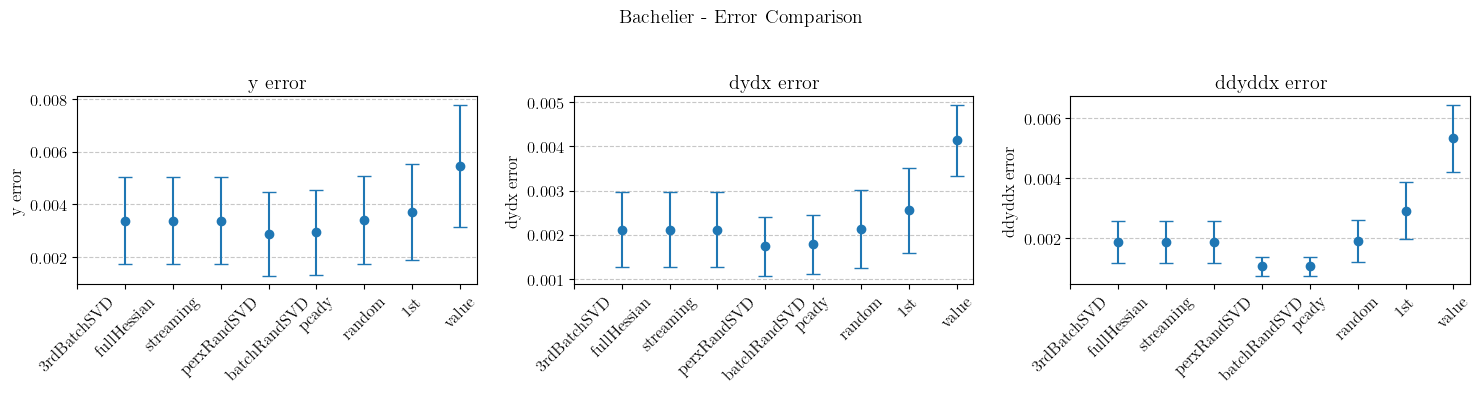

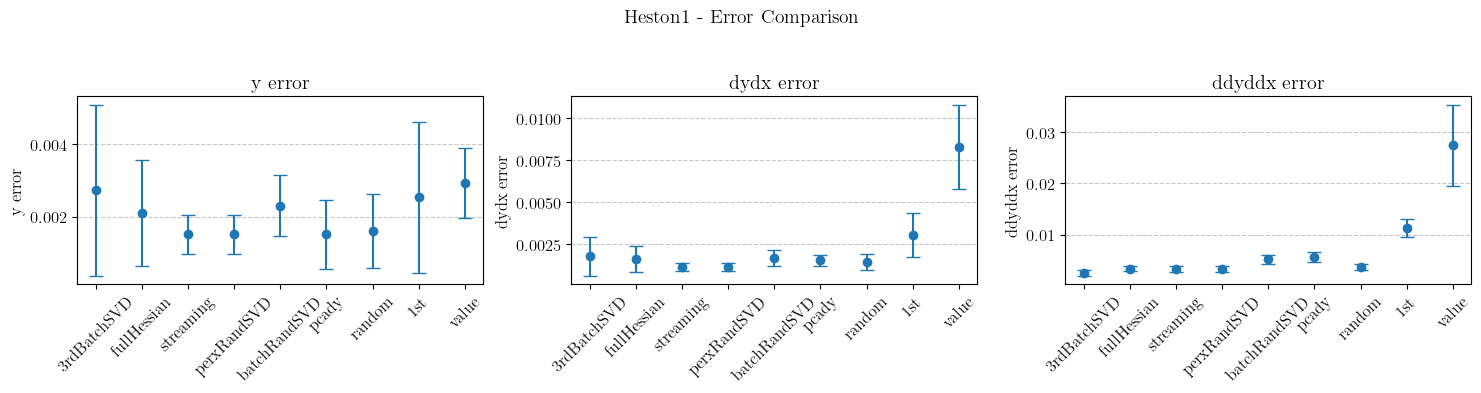

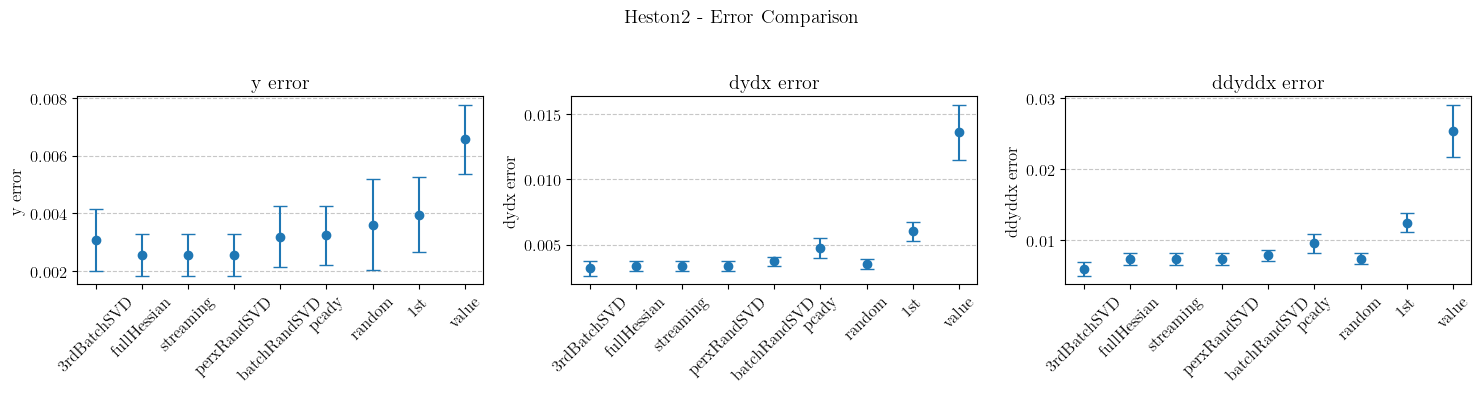

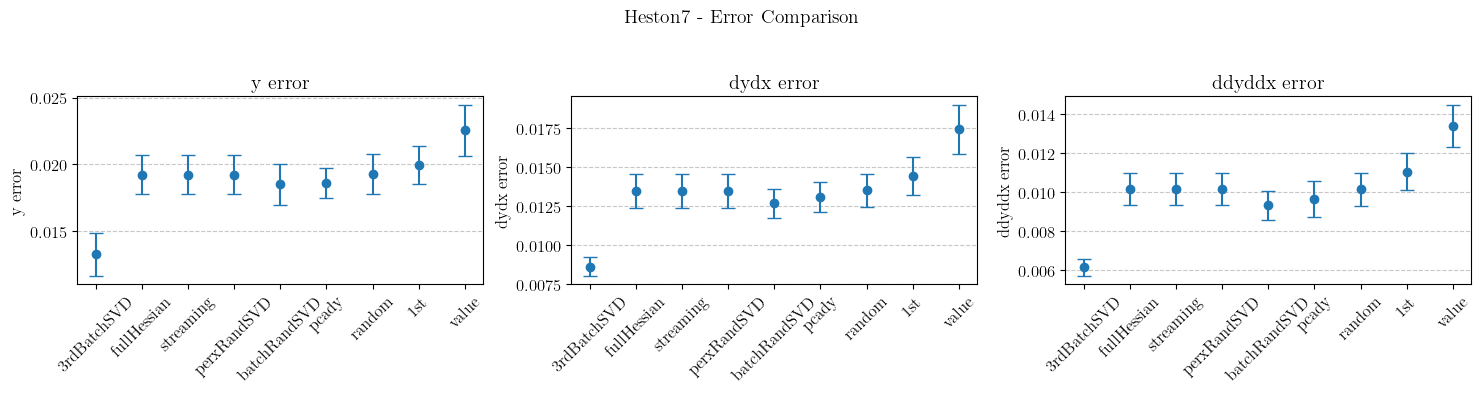

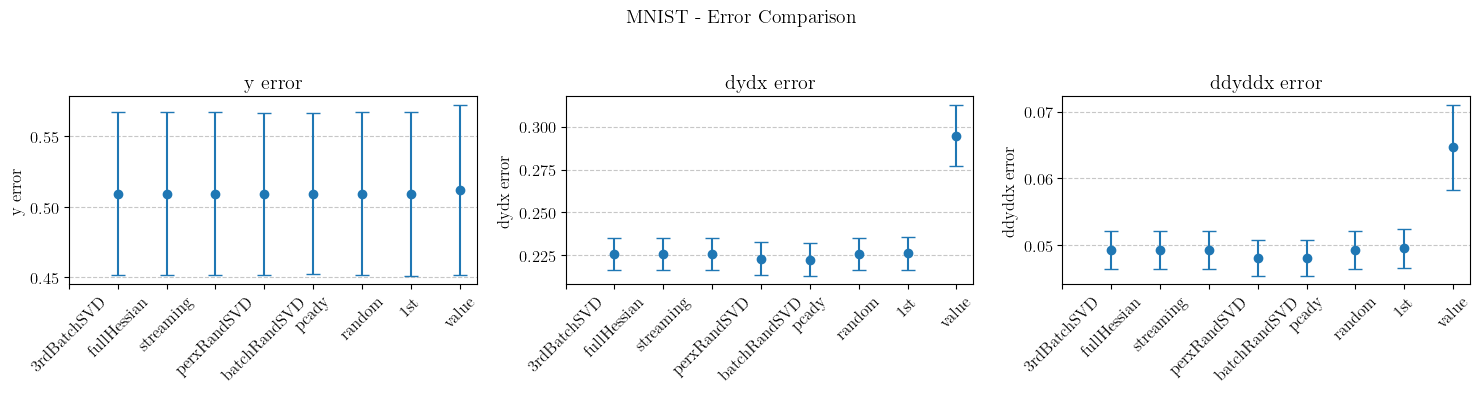

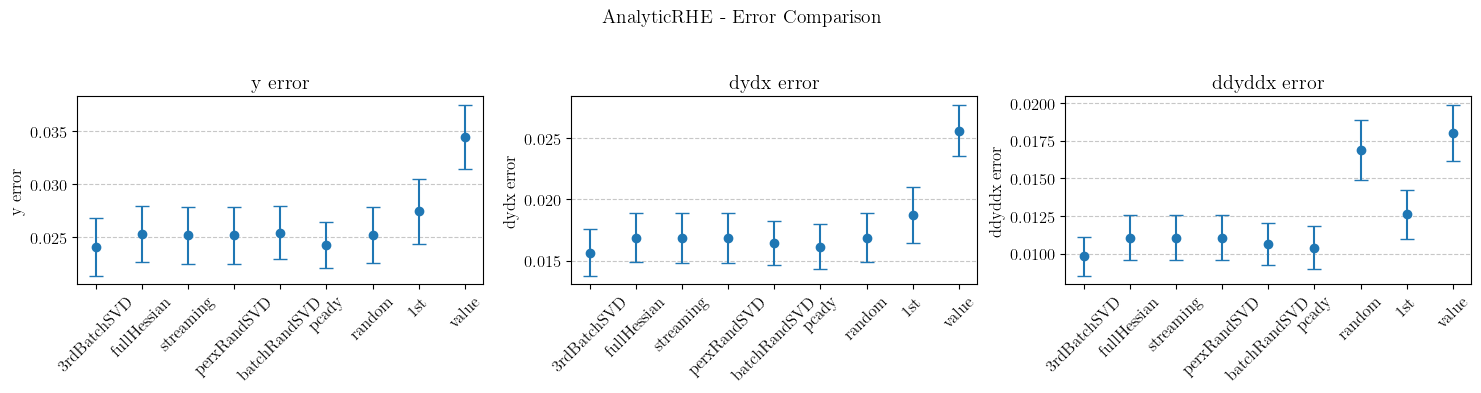

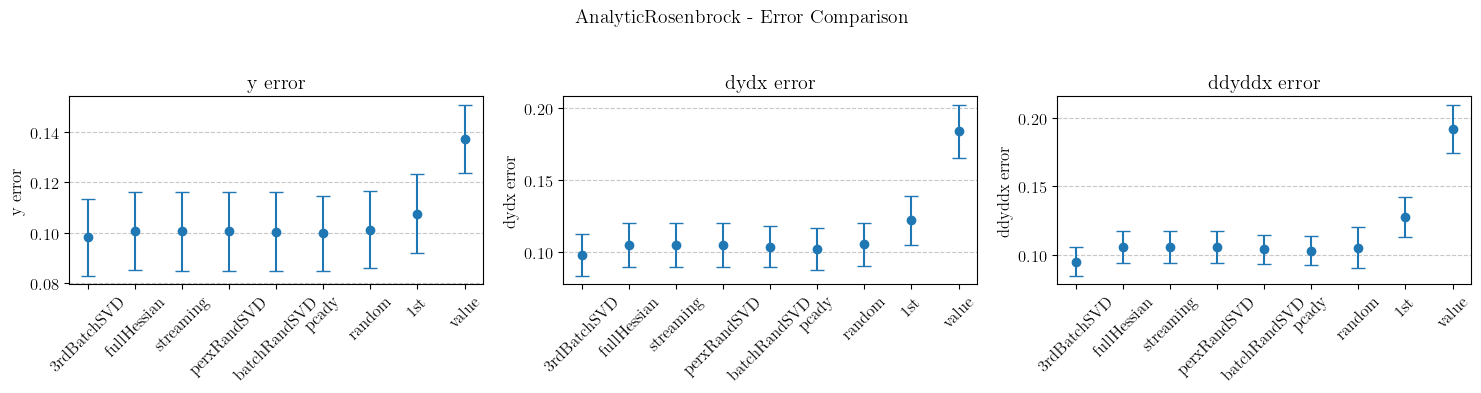

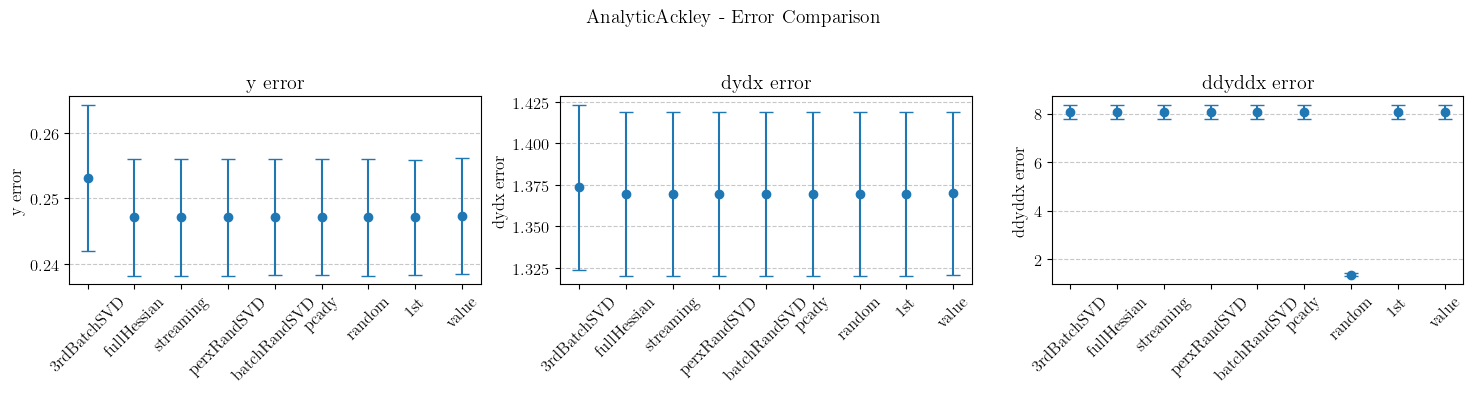

In [10]:
import matplotlib.pyplot as plt
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    error_types = [("y error", "y error"), ("dydx error", "dydx error"), ("ddyddx error", "ddyddx error")]

    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()


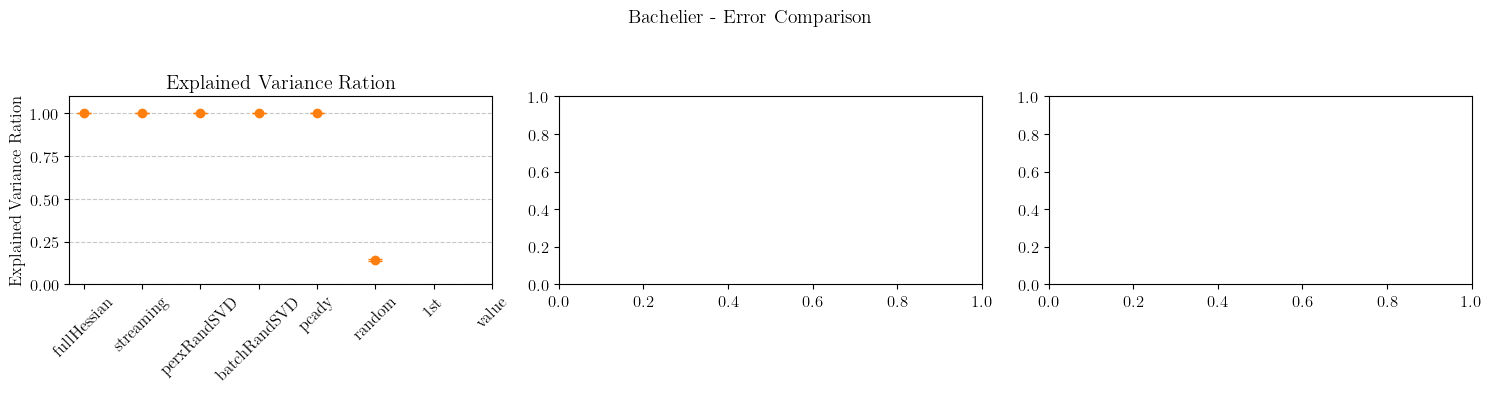

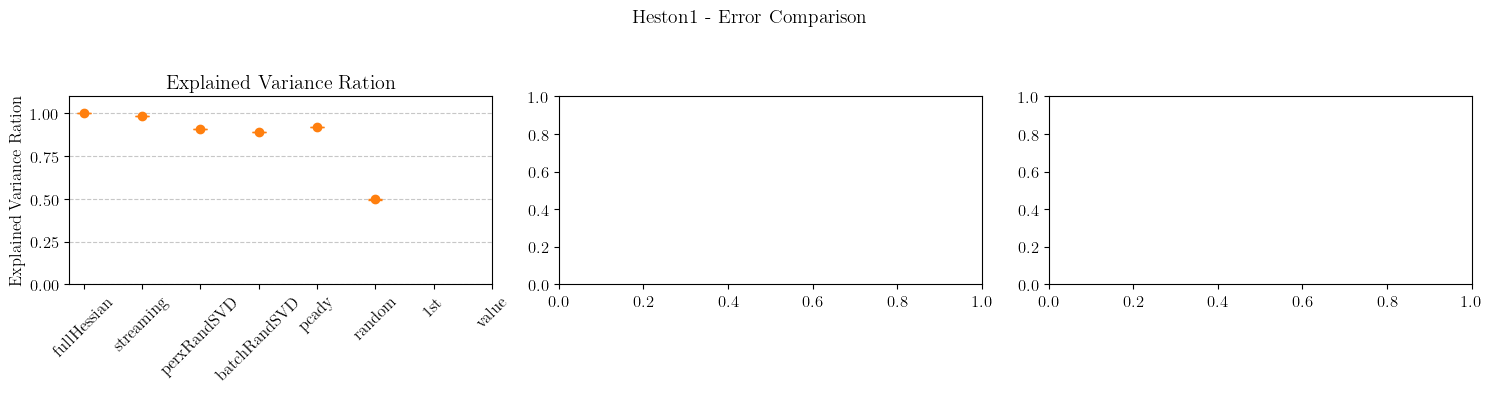

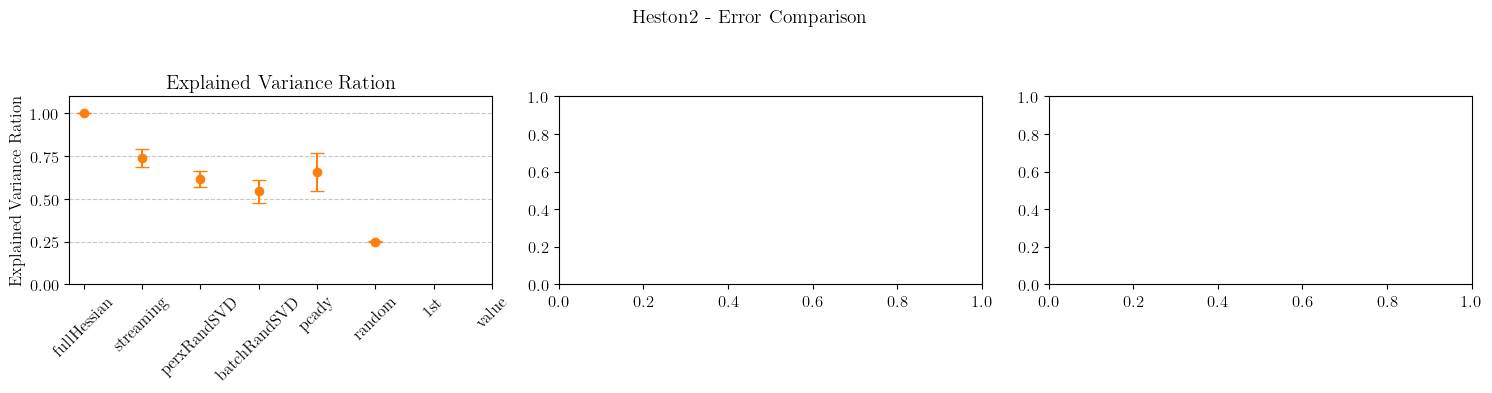

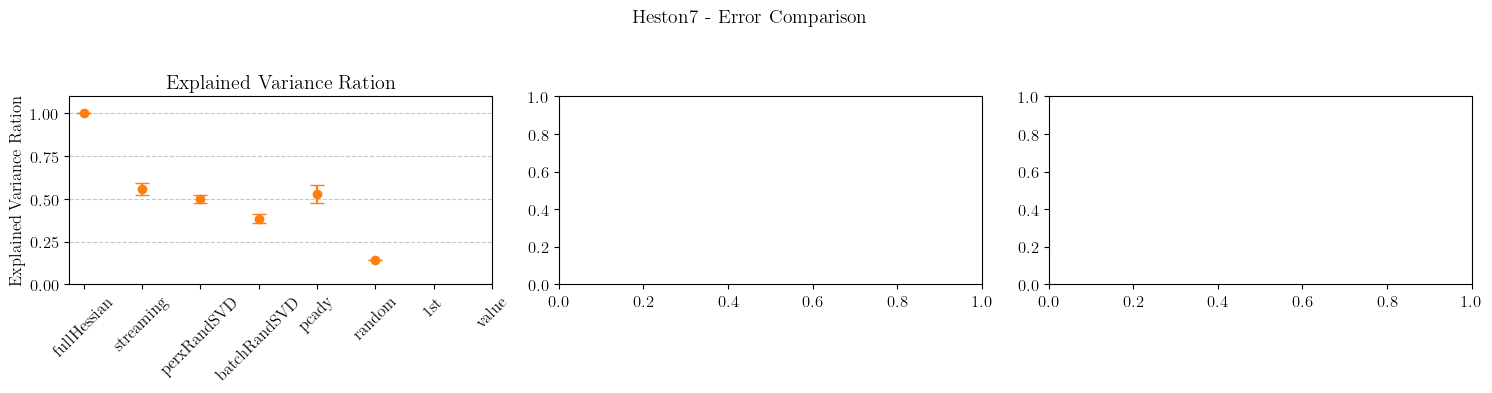

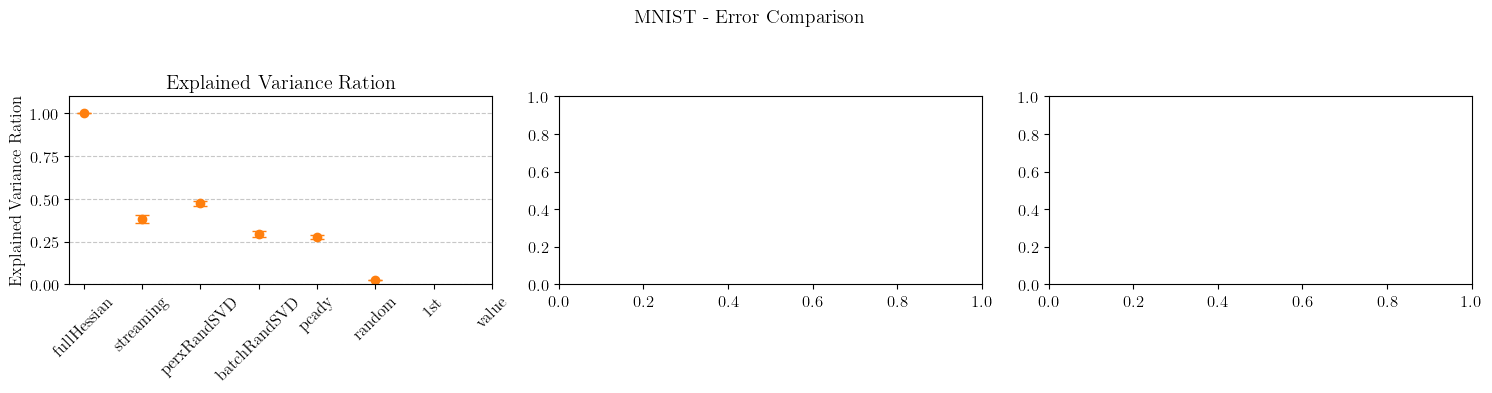

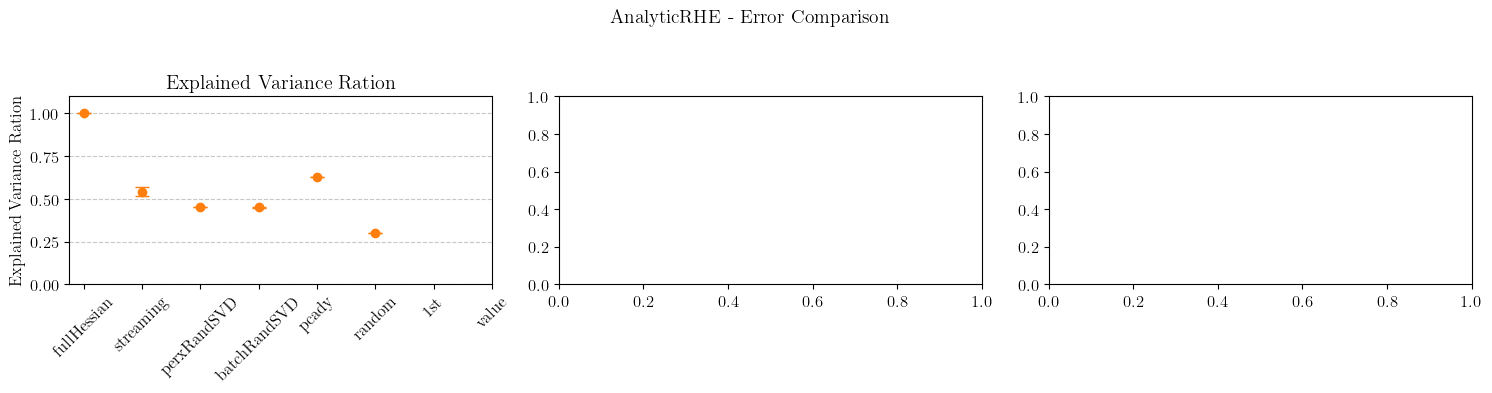

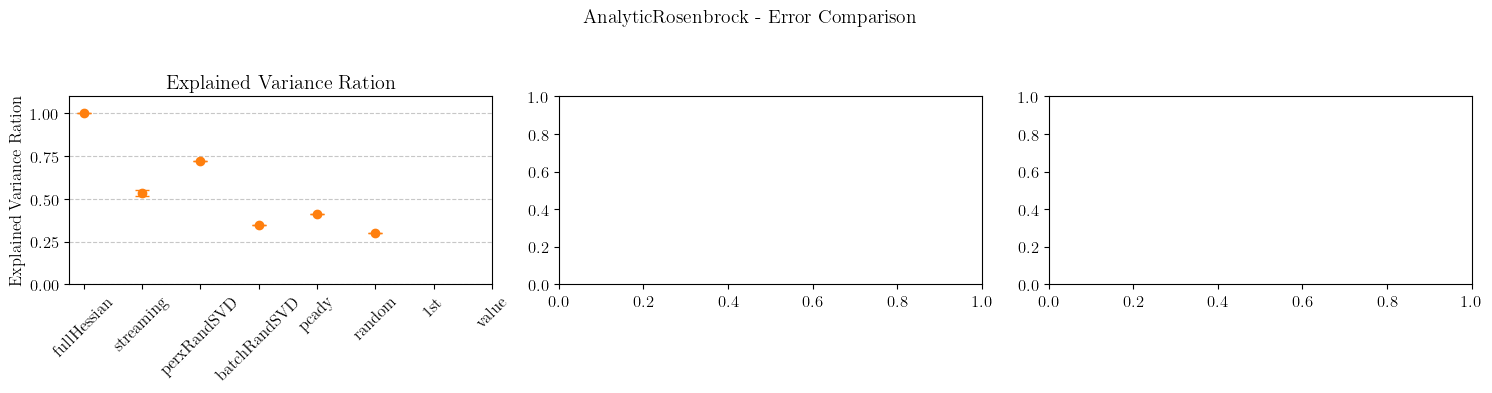

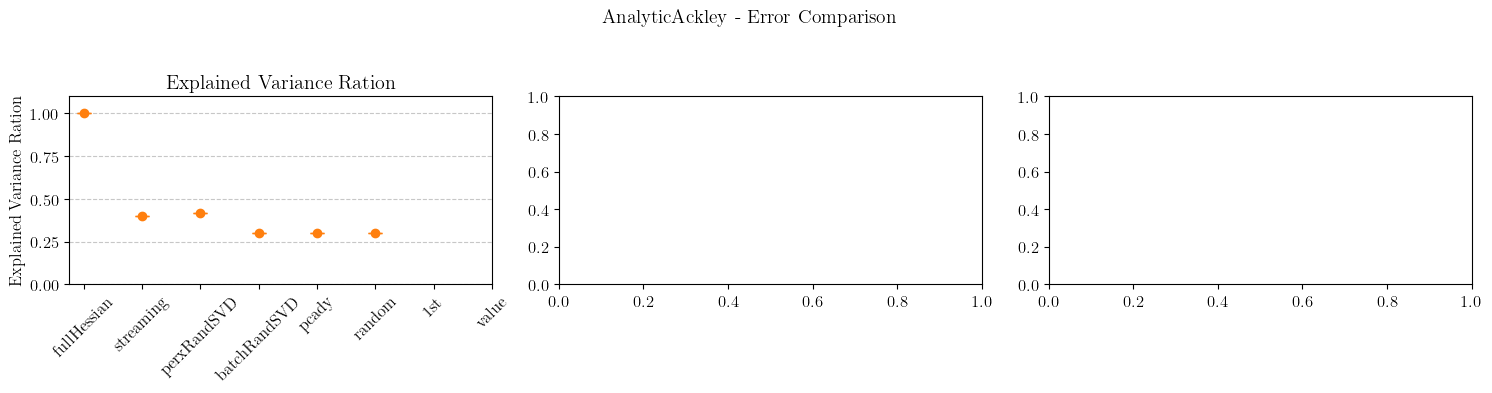

In [11]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    error_types = [("Explained Variance Ration", "evr")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    
    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='tab:orange')
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()
